Cell 1 — Environment check + load architecture

In [1]:
import torch
print(f"Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"Reserved: {torch.cuda.memory_reserved()/1e9:.2f} GB")

Allocated: 0.00 GB
Reserved: 0.00 GB


In [2]:
import torch
print(torch.cuda.is_available())
print(f"Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"Reserved: {torch.cuda.memory_reserved()/1e9:.2f} GB")

True
Allocated: 0.00 GB
Reserved: 0.00 GB


In [3]:
!pip install ultralytics -q
!pip install albumentations -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 605.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 7.2 MB/s eta 0:00:00


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from ultralytics import YOLO

def mem():
    return f"{torch.cuda.memory_allocated()/1e9:.2f} GB"

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Load architecture + backbone

In [5]:
model = YOLO('yolo12m.yaml')
print("After loading yolo arch:", mem())

class YOLOv12Backbone(nn.Module):
    def __init__(self, full_model):
        super().__init__()
        self.layers = nn.Sequential(*[full_model.model.model[i] for i in range(9)])
    def forward(self, x):
        return self.layers(x)

backbone = YOLOv12Backbone(model)
print("After building backbone:", mem())

After loading yolo arch: 0.00 GB
After building backbone: 0.00 GB


SimCLR model

In [6]:
class SimCLRModel(nn.Module):
    def __init__(self, backbone, feature_dim=512, projection_dim=128, hidden_dim=512):
        super().__init__()
        self.backbone = backbone
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.projection_head = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, projection_dim)
        )
    def forward(self, x):
        features = self.backbone(x)
        pooled = self.pool(features).flatten(1)
        return self.projection_head(pooled)

simclr_model = SimCLRModel(backbone)
print("After building simclr_model (still on CPU):", mem())

After building simclr_model (still on CPU): 0.00 GB


NT-Xent loss

In [7]:
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature
    def forward(self, z1, z2):
        N = z1.shape[0]
        z = torch.cat([z1, z2], dim=0)
        z = F.normalize(z, dim=1)
        sim = torch.matmul(z, z.T) / self.temperature
        mask = torch.eye(2*N, dtype=torch.bool, device=z.device)
        sim.masked_fill_(mask, -1e4)   # changed from -9e15 -> safe within float16 range
        positive_idx = torch.cat([torch.arange(N, 2*N), torch.arange(0, N)]).to(z.device)
        return F.cross_entropy(sim, positive_idx)

Data — lighter config this time

In [8]:
IMG_SIZE = 224   # standard SimCLR resolution

simclr_augment = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.5, 1.0), ratio=(0.9, 1.1), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=7, border_mode=0, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.8),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

class SimCLRPairDataset(Dataset):
    def __init__(self, image_paths, transform=simclr_augment):
        self.image_paths = image_paths
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        img = np.array(img)
        v1 = self.transform(image=img)['image']
        v2 = self.transform(image=img)['image']
        return v1, v2

partition = pd.read_csv('/kaggle/input/datasets/redwanahmed2025/groupj-partb-partition/partition.csv')
pool_df = partition[partition['role'] == 'pool']
pool_image_paths = pool_df['image_path'].tolist()
dataset = SimCLRPairDataset(pool_image_paths)
print("Dataset built, size:", len(dataset))

Dataset built, size: 8000


Config + dataloader

In [9]:
CONFIG = {
    'seed': 42, 'epochs': 30, 'batch_size': 64, 'lr': 3e-4,
    'temperature': 0.5, 'weight_decay': 1e-6, 'projection_dim': 128, 'img_size': 224,
}
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
train_loader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True,
                           num_workers=2, pin_memory=True, drop_last=True)
print("Batches per epoch:", len(train_loader))

Batches per epoch: 125


Device + move model — watch memory here specifically

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Before .to(device):", mem())
simclr_model = simclr_model.to(device)
print("After .to(device):", mem())

Before .to(device): 0.00 GB
After .to(device): 0.05 GB


Optimizer + scaler

In [11]:
criterion = NTXentLoss(temperature=CONFIG['temperature'])
optimizer = torch.optim.Adam(simclr_model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scaler = torch.amp.GradScaler('cuda')

Smoke test

In [12]:
simclr_model.train()
v1_batch, v2_batch = next(iter(train_loader))
v1_batch, v2_batch = v1_batch.to(device), v2_batch.to(device)
print("After batch to device:", mem())

optimizer.zero_grad()
with torch.amp.autocast('cuda'):
    z1 = simclr_model(v1_batch)
    z2 = simclr_model(v2_batch)
    loss = criterion(z1, z2)
print("Loss:", loss.item(), "| After forward:", mem())

scaler.scale(loss).backward()
scaler.step(optimizer)
scaler.update()
print("Success. After backward+step:", mem())

After batch to device: 0.12 GB
Loss: 4.884765625 | After forward: 5.59 GB
Success. After backward+step: 0.24 GB


the real training loop (30 epochs, with loss logging)

In [13]:
import time

CONFIG['epochs'] = 30
loss_history = []

simclr_model.train()
start_time = time.time()

for epoch in range(CONFIG['epochs']):
    epoch_loss = 0.0
    for batch_idx, (v1, v2) in enumerate(train_loader):
        v1, v2 = v1.to(device), v2.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            z1 = simclr_model(v1)
            z2 = simclr_model(v2)
            loss = criterion(z1, z2)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    elapsed = (time.time() - start_time) / 60
    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Loss: {avg_loss:.4f} | Elapsed: {elapsed:.1f} min")

    # Checkpoint every 5 epochs in case the session interrupts — Kaggle sessions can time out
    if (epoch + 1) % 5 == 0:
        torch.save(backbone.state_dict(), f'/kaggle/working/simclr_backbone_epoch{epoch+1}.pt')
        print(f"  Checkpoint saved at epoch {epoch+1}")

print("Training complete.")

Epoch 1/30 | Loss: 4.0573 | Elapsed: 0.9 min
Epoch 2/30 | Loss: 3.5600 | Elapsed: 1.9 min
Epoch 3/30 | Loss: 3.4133 | Elapsed: 2.9 min
Epoch 4/30 | Loss: 3.3296 | Elapsed: 4.0 min
Epoch 5/30 | Loss: 3.2530 | Elapsed: 5.0 min
  Checkpoint saved at epoch 5
Epoch 6/30 | Loss: 3.1962 | Elapsed: 6.1 min
Epoch 7/30 | Loss: 3.1576 | Elapsed: 7.1 min
Epoch 8/30 | Loss: 3.1254 | Elapsed: 8.1 min
Epoch 9/30 | Loss: 3.1045 | Elapsed: 9.2 min
Epoch 10/30 | Loss: 3.0881 | Elapsed: 10.2 min
  Checkpoint saved at epoch 10
Epoch 11/30 | Loss: 3.0679 | Elapsed: 11.3 min
Epoch 12/30 | Loss: 3.0570 | Elapsed: 12.3 min
Epoch 13/30 | Loss: 3.0455 | Elapsed: 13.4 min
Epoch 14/30 | Loss: 3.0385 | Elapsed: 14.4 min
Epoch 15/30 | Loss: 3.0343 | Elapsed: 15.4 min
  Checkpoint saved at epoch 15
Epoch 16/30 | Loss: 3.0249 | Elapsed: 16.5 min
Epoch 17/30 | Loss: 3.0186 | Elapsed: 17.5 min
Epoch 18/30 | Loss: 3.0120 | Elapsed: 18.5 min
Epoch 19/30 | Loss: 3.0082 | Elapsed: 19.6 min
Epoch 20/30 | Loss: 3.0002 | Elap

In [14]:
# add as the last line, after the training loop
torch.save(backbone.state_dict(), '/kaggle/working/simclr_backbone_final.pt')
print("Final backbone saved.")

Final backbone saved.


Confirm the checkpoints exist and check the loss curve

In [15]:
import os
print(os.listdir('/kaggle/working'))

['simclr_backbone_epoch30.pt', 'simclr_backbone_final.pt', 'simclr_backbone_epoch15.pt', 'simclr_backbone_epoch10.pt', 'simclr_backbone_epoch5.pt', 'simclr_backbone_epoch25.pt', 'simclr_backbone_epoch20.pt', '__notebook__.ipynb']


In [16]:
print("Final loss:", loss_history[-1])
print("Loss history:", loss_history)

Final loss: 2.9705777587890627
Loss history: [4.057309814453125, 3.5600166015625, 3.41327978515625, 3.329609375, 3.2529761962890626, 3.1962376708984377, 3.157587158203125, 3.1253890380859377, 3.1044805908203124, 3.0881126708984374, 3.0679451904296875, 3.056955810546875, 3.0454993896484375, 3.0384583740234374, 3.0343160400390623, 3.0248905029296873, 3.0185533447265627, 3.0120255126953124, 3.0081729736328127, 3.0002415771484374, 2.9972674560546877, 2.990295654296875, 2.9939659423828124, 2.9893245849609373, 2.986337890625, 2.9802242431640624, 2.9806624755859374, 2.9731104736328127, 2.970186767578125, 2.9705777587890627]


Plot the loss curve

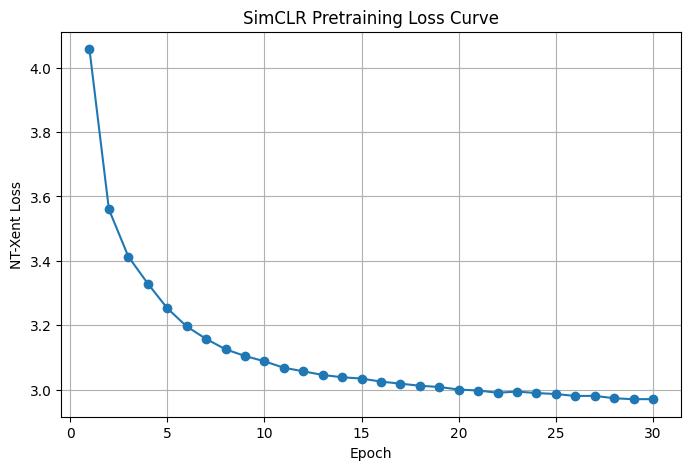

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(loss_history)+1), loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("NT-Xent Loss")
plt.title("SimCLR Pretraining Loss Curve")
plt.grid(True)
plt.savefig('/kaggle/working/simclr_loss_curve.png')
plt.show()

extract embeddings from a validation-image sample

In [18]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Use validation images for diagnostics (never touch test)
val_df = partition[partition['role'] == 'val']
val_image_paths = val_df['image_path'].tolist()

# Sample a manageable subset for t-SNE (300-500 images is plenty and keeps it fast)
np.random.seed(42)
sample_idx = np.random.choice(len(val_image_paths), size=min(400, len(val_image_paths)), replace=False)
sample_paths = [val_image_paths[i] for i in sample_idx]

# We also want the class labels for these images, to color the scatter plot meaningfully
sample_labels = val_df.iloc[sample_idx][['has_cavities', 'has_damage', 'has_infection', 'has_wisdom']].values

# Simple deterministic transform for embedding extraction (no augmentation — we want the "clean" representation)
eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

def extract_embedding(path, model, transform, device):
    img = Image.open(path).convert('RGB')
    img = np.array(img)
    tensor = transform(image=img)['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        feat = model.backbone(tensor)          # (1, 512, H, W)
        pooled = model.pool(feat).flatten(1)    # (1, 512) — use backbone features, not projection head output
    return pooled.cpu().numpy().squeeze()

simclr_model.eval()
embeddings = np.array([extract_embedding(p, simclr_model, eval_transform, device) for p in sample_paths])
print("Embeddings shape:", embeddings.shape)

Embeddings shape: (400, 512)


t-SNE scatter plot, colored by class presence

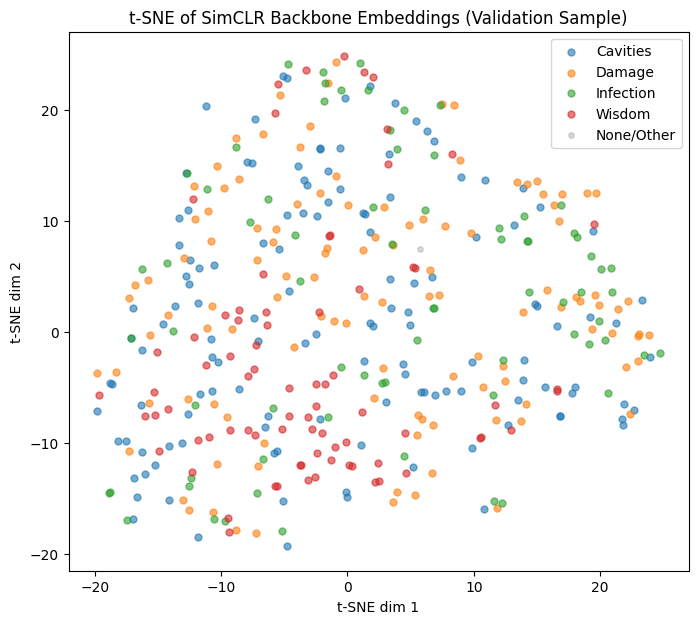

In [19]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
embeddings_2d = tsne.fit_transform(embeddings)

# Build a simple color label: which class dominates each image (for visualization only)
class_names = ['Cavities', 'Damage', 'Infection', 'Wisdom']
dominant_class = sample_labels.argmax(axis=1)  # crude but fine for a diagnostic plot
# Images with no positive class (all zeros) get labeled separately
has_any = sample_labels.sum(axis=1) > 0
dominant_class_display = np.where(has_any, dominant_class, -1)

plt.figure(figsize=(8, 7))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for i, name in enumerate(class_names):
    mask = dominant_class_display == i
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], label=name, alpha=0.6, s=25, c=colors[i])
mask_none = dominant_class_display == -1
plt.scatter(embeddings_2d[mask_none, 0], embeddings_2d[mask_none, 1], label='None/Other', alpha=0.3, s=15, c='gray')

plt.legend()
plt.title("t-SNE of SimCLR Backbone Embeddings (Validation Sample)")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.savefig('/kaggle/working/simclr_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

nearest-neighbor retrieval panel

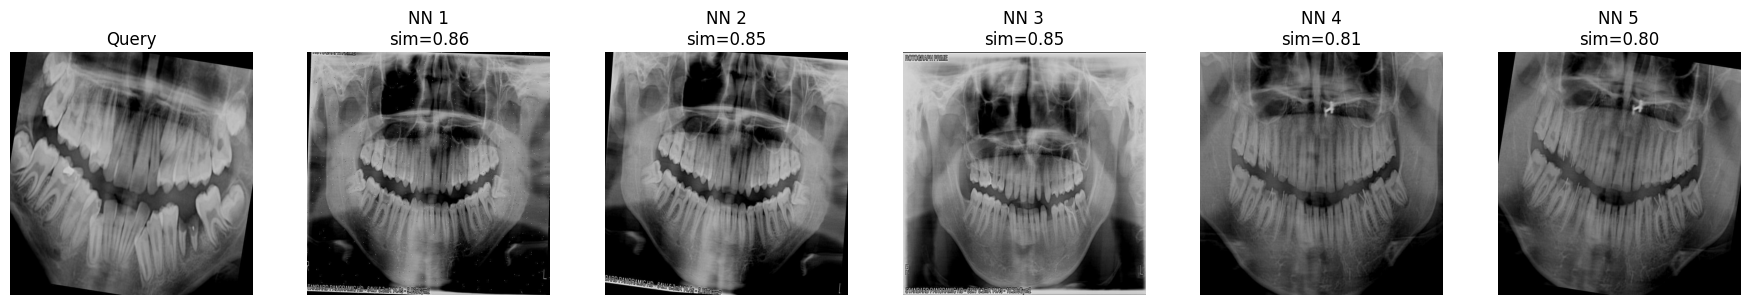

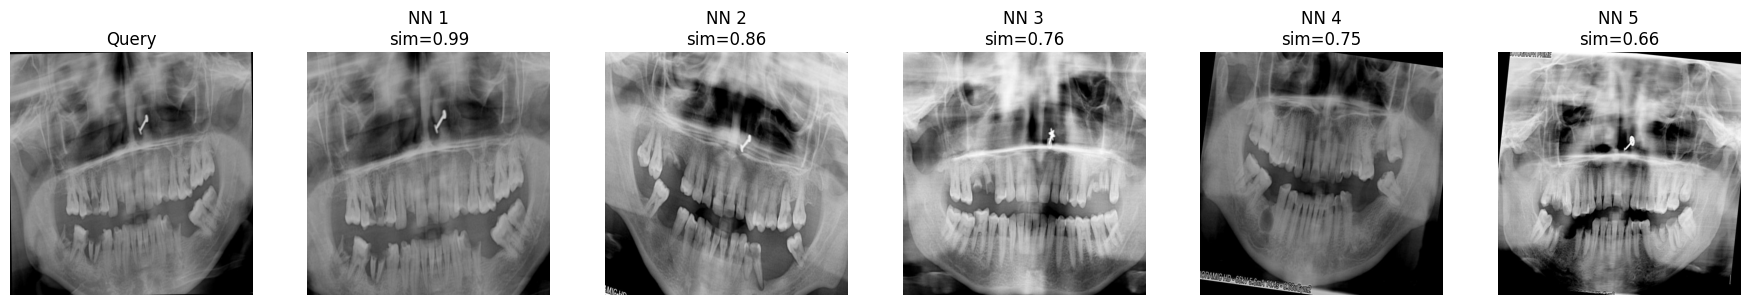

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

def show_retrieval_panel(query_idx, embeddings, paths, top_k=5):
    sims = cosine_similarity(embeddings[query_idx:query_idx+1], embeddings)[0]
    top_indices = np.argsort(-sims)[1:top_k+1]  # exclude the query itself (index 0 after sort)

    fig, axes = plt.subplots(1, top_k+1, figsize=(3*(top_k+1), 3))

    query_img = np.array(Image.open(paths[query_idx]).convert('RGB'))
    axes[0].imshow(query_img)
    axes[0].set_title("Query")
    axes[0].axis('off')

    for i, idx in enumerate(top_indices):
        img = np.array(Image.open(paths[idx]).convert('RGB'))
        axes[i+1].imshow(img)
        axes[i+1].set_title(f"NN {i+1}\nsim={sims[idx]:.2f}")
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.savefig(f'/kaggle/working/simclr_retrieval_query{query_idx}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Show retrieval for a couple different query images
show_retrieval_panel(query_idx=0, embeddings=embeddings, paths=sample_paths, top_k=5)
show_retrieval_panel(query_idx=50, embeddings=embeddings, paths=sample_paths, top_k=5)

## Representation Diagnostics — Commentary

The t-SNE projection shows weak, non-random structure by class (e.g., a mild concentration 
of Wisdom-positive images on the right side of the embedding space), but no clean separation 
between classes. This is expected: SimCLR's contrastive objective never has access to labels, 
so any class-aligned structure is incidental to learning general visual similarity, not a 
diagnostic signal.

The nearest-neighbour retrieval panel provides stronger evidence that the backbone learned 
meaningful structure. Both query images retrieve neighbours with closely matching framing, 
tooth arrangement, and contrast style; notably, one query retrieves a neighbour sharing the 
same distinctive metallic artifact near the same anatomical location, suggesting the backbone 
is sensitive to fine-grained structural detail beyond coarse image statistics.

We interpret the gap between the two diagnostics as a limitation of 2D t-SNE compression rather 
than an absence of structure in the full 512-dim embedding space — retrieval operates directly 
on the full-dimensional embeddings and reveals structure the 2D projection obscures.

In [21]:
import shutil

shutil.copy('/kaggle/working/simclr_backbone_final.pt', '/kaggle/working/simclr_backbone.pt')
print("Copied to standard name.")
print(os.listdir('/kaggle/working'))

Copied to standard name.
['simclr_loss_curve.png', 'simclr_backbone_epoch30.pt', 'simclr_backbone_final.pt', 'simclr_tsne.png', 'simclr_backbone_epoch15.pt', 'simclr_retrieval_query0.png', 'simclr_backbone_epoch10.pt', 'simclr_retrieval_query50.png', 'simclr_backbone_epoch5.pt', 'simclr_backbone_epoch25.pt', 'simclr_backbone_epoch20.pt', '__notebook__.ipynb', 'simclr_backbone.pt']
